# 04 — AVIRIS-NG × LVIS matching and sensor fusion

## BioSCape 2023 | *Leucadendron argenteum* | Table Mountain National Park

This notebook brings together the two preceding analyses:

- **Part 2:** LVIS RH98 canopy-height analysis.
- **Part 3:** AVIRIS-NG hyperspectral classification.

The integration asks whether LVIS canopy height adds useful information to the hyperspectral identification of *Leucadendron argenteum*.

Two analyses are kept separate:

1. **Feature-level fusion** — RH98 is added to the hyperspectral predictors and enters the classifier.
2. **Post-classification structural filtering** — the hyperspectral prediction is made first, then RH98 is used only to reject structurally implausible target predictions.

### Spectral rule used throughout this notebook

The fusion analysis uses the **same 324 retained AVIRIS-NG bands produced by Part 3**. It does not return to the original 425-band file and does not create another bad-band mask.

The notebook therefore loads `spectral_library_analysis_324bands.csv` and `retained_bands_324.csv` directly. It stops if the band table does not contain exactly 324 bands or if those columns are not present in the saved analysis library.

## 1. Packages, paths and analysis settings

All editable settings are kept here. The paths follow the directory structure used by the RH98 and hyperspectral notebooks.

The headline LVIS-to-AVIRIS matching radius is 6 m: approximately 4 m for the LVIS footprint radius plus a 2 m allowance for horizontal geolocation error. A radius sweep is retained to show how the result changes as matching becomes more permissive.


In [1]:
from pathlib import Path
import glob
import re
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio

from rasterio.transform import from_origin
from scipy import stats
from scipy.spatial import cKDTree

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")


# -------------------------------------------------------------------
# Project folders
# -------------------------------------------------------------------

project_root = Path.cwd()

hyperspectral_table_dir = (
    project_root
    / "Data"
    / "Hyperspectral"
    / "Outputs_324bands"
    / "Tables"
)

spectral_library_csv = (
    hyperspectral_table_dir
    / "spectral_library_analysis_324bands.csv"
)

retained_bands_csv = (
    hyperspectral_table_dir
    / "retained_bands_324.csv"
)

lvis_dir = (
    project_root
    / "Data"
    / "LVIS"
)

# Structural upper-bound table produced by the RH98 analysis notebook.
# This notebook does not independently reconstruct or round the threshold.
structural_height_bound_path = (
    project_root
    / "outputs"
    / "01_lvis_pairing2"
    / "tables"
    / "T_structural_height_bound.csv"
)

output_dir = (
    project_root
    / "outputs"
    / "02_matching_fusion"
)

table_dir = output_dir / "tables"
figure_dir = output_dir / "figures"
raster_dir = output_dir / "rasters"

for folder in [output_dir, table_dir, figure_dir, raster_dir]:
    folder.mkdir(parents=True, exist_ok=True)


# -------------------------------------------------------------------
# Species and spectral settings
# -------------------------------------------------------------------

species_column = "Scientific.Names"
latitude_column = "Latitude"
longitude_column = "Longitude"

target_species = "Leucadendron argenteum"

expected_retained_bands = 324
n_pcs = 10


# -------------------------------------------------------------------
# LVIS settings
# -------------------------------------------------------------------

working_crs = "EPSG:32734"          # UTM Zone 34S; distance is in metres

lvis_footprint_diameter_m = 8.0
lvis_geolocation_error_m = 2.0

match_radius_m = 6.0
radius_sweep_m = (4.0, 6.0, 8.0, 12.5, 25.0)

minimum_lvis_sensitivity = 0.90
rh98_min_m = 0.0
rh98_max_m = 30.0

# This padding only reduces how much LVIS data are read from disk.
# It does NOT determine which observations receive RH98.
lvis_search_padding_m = 200.0

# Grid RH98 close to the physical LVIS footprint scale.
rh98_grid_resolution_m = 8.0

# Read the large LVIS archive in chunks to keep memory use manageable.
lvis_chunk_rows = 500_000
lvis_progress_every = 50
max_lvis_granules = None

lvis_cache_csv = (
    output_dir
    / "lvis_near_spectra.csv"
)


# -------------------------------------------------------------------
# Cross-validation settings
# -------------------------------------------------------------------

cv_splits = 5
cv_repeats = 10
random_state = 42


print(f"324-band library : {spectral_library_csv}")
print(f"Retained bands   : {retained_bands_csv}")
print(f"LVIS directory   : {lvis_dir}")
print(f"Structural bound : {structural_height_bound_path}")
print(f"Output directory : {output_dir}")

print(
    f"\nLVIS footprint diameter : "
    f"{lvis_footprint_diameter_m:.1f} m"
)

print(
    f"Headline matching radius: "
    f"{match_radius_m:.1f} m"
)


324-band library : /Users/phemelo/Documents/LesHyperion/Data/Hyperspectral/Outputs_324bands/Tables/spectral_library_analysis_324bands.csv
Retained bands   : /Users/phemelo/Documents/LesHyperion/Data/Hyperspectral/Outputs_324bands/Tables/retained_bands_324.csv
LVIS directory   : /Users/phemelo/Documents/LesHyperion/Data/LVIS
Structural bound : /Users/phemelo/Documents/LesHyperion/outputs/01_lvis_pairing2/tables/T_structural_height_bound.csv
Output directory : /Users/phemelo/Documents/LesHyperion/outputs/02_matching_fusion

LVIS footprint diameter : 8.0 m
Headline matching radius: 6.0 m


## 2. Load the exact 324-band hyperspectral analysis library

Part 2 has already established which wavelengths belong in the classification analysis. Repeating band filtering here would create a second, potentially inconsistent definition of the spectral predictor set.

This section therefore treats the Part 2 outputs as the source of truth. The retained-band table supplies the ordered 324 band names and wavelengths; the analysis library supplies the observation metadata and reflectance values.


In [2]:
if not spectral_library_csv.exists():
    raise FileNotFoundError(
        f"Could not find {spectral_library_csv}. "
        "Run the hyperspectral-classification notebook first."
    )

if not retained_bands_csv.exists():
    raise FileNotFoundError(
        f"Could not find {retained_bands_csv}. "
        "Run the hyperspectral-classification notebook first."
    )


spectral_library = pd.read_csv(
    spectral_library_csv
)

retained_bands = pd.read_csv(
    retained_bands_csv
)


# The band table written by Part 2 contains the original band-column name
# and its wavelength in nanometres.
required_band_fields = {
    "band_column",
    "wavelength_nm",
}

if not required_band_fields.issubset(retained_bands.columns):
    raise KeyError(
        "The retained-band table must contain "
        "'band_column' and 'wavelength_nm'."
    )


band_columns = (
    retained_bands["band_column"]
    .astype(str)
    .tolist()
)

wavelengths_nm = (
    retained_bands["wavelength_nm"]
    .to_numpy(float)
)


# Stop immediately if the fusion notebook is not using exactly 324 bands.
if len(band_columns) != expected_retained_bands:
    raise ValueError(
        f"Expected {expected_retained_bands} retained bands, "
        f"but found {len(band_columns)}."
    )


missing_bands = [
    band
    for band in band_columns
    if band not in spectral_library.columns
]

if missing_bands:
    raise KeyError(
        "The 324-band analysis library is missing these retained bands: "
        + ", ".join(missing_bands[:10])
    )


required_metadata = {
    species_column,
    latitude_column,
    longitude_column,
}

missing_metadata = (
    required_metadata
    .difference(spectral_library.columns)
)

if missing_metadata:
    raise KeyError(
        "The analysis library is missing required metadata fields: "
        + ", ".join(sorted(missing_metadata))
    )


if target_species not in spectral_library[species_column].astype(str).values:
    raise ValueError(
        f"{target_species} is not present in the analysis library."
    )


print(
    f"Loaded {len(spectral_library):,} observations "
    f"with exactly {len(band_columns)} retained bands."
)

print(
    f"Retained wavelength range: "
    f"{wavelengths_nm.min():.0f}-{wavelengths_nm.max():.0f} nm"
)

print(
    f"{target_species} observations: "
    f"{(spectral_library[species_column].astype(str) == target_species).sum():,}"
)


Loaded 1,229 observations with exactly 324 retained bands.
Retained wavelength range: 452-2396 nm
Leucadendron argenteum observations: 50


### 2.1 Reproduce the Part 2 spectral transformation

The 324 retained reflectance values are converted to numeric form, remaining missing values are set to zero after the Part 2 row-level quality control, and each spectrum is vector-normalised by its Euclidean norm.

No wavelength selection happens here. The matrix must remain 324 columns wide.


In [3]:
spectral_matrix = (
    spectral_library[band_columns]
    .apply(pd.to_numeric, errors="coerce")
    .to_numpy(float)
)

# Match the hyperspectral notebook: any remaining missing reflectance values
# are replaced with zero after the observation-level quality-control step.
spectral_matrix = np.nan_to_num(
    spectral_matrix,
    nan=0.0,
)

# Vector normalisation used in Part 2.
spectral_norms = np.sqrt(
    (spectral_matrix ** 2)
    .sum(axis=1, keepdims=True)
)

spectral_norms[
    spectral_norms == 0
] = 1.0

spectral_matrix_normalised = (
    spectral_matrix
    / spectral_norms
)

species_labels = (
    spectral_library[species_column]
    .astype(str)
    .to_numpy()
)


if spectral_matrix_normalised.shape[1] != expected_retained_bands:
    raise ValueError(
        "The spectral model matrix is not 324 bands wide."
    )


print(
    f"Normalised matrix: "
    f"{spectral_matrix_normalised.shape[0]:,} observations × "
    f"{spectral_matrix_normalised.shape[1]} bands"
)


Normalised matrix: 1,229 observations × 324 bands


## 3. Project the AVIRIS-NG observations

The spectral-library coordinates are stored as longitude and latitude. Spatial matching is performed after projecting them to UTM Zone 34S, so distances are calculated in metres rather than degrees.

The broad 200 m buffer below is only a computational search window for reading LVIS granules. The actual matching radii are applied later.


In [4]:
aviris_points = gpd.GeoDataFrame(
    spectral_library[
        [
            species_column,
            latitude_column,
            longitude_column,
        ]
    ].copy(),
    geometry=gpd.points_from_xy(
        spectral_library[longitude_column],
        spectral_library[latitude_column],
    ),
    crs="EPSG:4326",
).to_crs(working_crs)


search_geometry = (
    aviris_points.geometry
    .buffer(lvis_search_padding_m)
)

lon_min, lat_min, lon_max, lat_max = (
    gpd.GeoSeries(
        search_geometry,
        crs=working_crs,
    )
    .to_crs("EPSG:4326")
    .total_bounds
)


print(
    f"LVIS reading window "
    f"({lvis_search_padding_m:.0f} m computational padding):"
)

print(
    f"  longitude: "
    f"{lon_min:.5f} to {lon_max:.5f}"
)

print(
    f"  latitude : "
    f"{lat_min:.5f} to {lat_max:.5f}"
)


LVIS reading window (200 m computational padding):
  longitude: 18.31590 to 18.49612
  latitude : -34.33142 to -33.89908


## 4. Read and filter the LVIS shots

The LVIS archive is read in chunks because loading all granules into memory first is unnecessary and can exhaust the kernel.

Only shots near the spectral observations are retained. The basic RH98 quality logic follows Part 1: finite ground elevation where available, RH98 within 0–30 m, and sensitivity of at least 0.90 where the sensitivity field exists.

The reduced LVIS table is cached after the first complete run.


In [5]:
# Only a small set of LVIS fields is needed for this integration.
lvis_fields_needed = {
    "GLON",
    "GLAT",
    "ZG",
    "ZT",
    "RH98",
    "SENSITIVITY",
    "COMPLEXITY",
    "RANGE",
}


def read_lvis_column_names(file_path):
    """Return the LVIS column names written in the text-file header."""

    column_names = None

    with open(
        file_path,
        "r",
        encoding="utf-8",
        errors="ignore",
    ) as lvis_file:

        for line in lvis_file:

            if line.startswith("#"):
                column_names = (
                    line
                    .lstrip("#")
                    .strip()
                    .split()
                )
            else:
                break

    return column_names


if lvis_cache_csv.exists():

    lvis = pd.read_csv(
        lvis_cache_csv
    )

    print(
        f"Loaded {len(lvis):,} filtered LVIS shots "
        f"from {lvis_cache_csv}"
    )

else:

    lvis_files = sorted(
        glob.glob(str(lvis_dir / "*.TXT"))
        + glob.glob(str(lvis_dir / "*.txt"))
    )

    if max_lvis_granules is not None:
        lvis_files = lvis_files[
            :max_lvis_granules
        ]

    if not lvis_files:
        raise FileNotFoundError(
            f"No LVIS text granules were found in {lvis_dir.resolve()}."
        )


    retained_chunks = []
    rows_read = 0

    print(
        f"Streaming {len(lvis_files):,} LVIS granules "
        f"in chunks of {lvis_chunk_rows:,} rows."
    )


    for file_number, file_path in enumerate(
        lvis_files,
        start=1,
    ):

        column_names = read_lvis_column_names(
            file_path
        )

        if not column_names:
            print(
                f"Skipping {Path(file_path).name}: "
                "header could not be read."
            )
            continue


        columns_to_keep = [
            column
            for column in column_names
            if column in lvis_fields_needed
        ]

        if "RH98" not in columns_to_keep:
            print(
                f"Skipping {Path(file_path).name}: "
                "RH98 is not present."
            )
            continue


        column_positions = [
            index
            for index, column in enumerate(column_names)
            if column in columns_to_keep
        ]


        try:

            lvis_chunks = pd.read_csv(
                file_path,
                sep=r"\s+",
                comment="#",
                names=column_names,
                header=None,
                usecols=column_positions,
                dtype="float32",
                on_bad_lines="skip",
                chunksize=lvis_chunk_rows,
            )


            for lvis_chunk in lvis_chunks:

                rows_read += len(lvis_chunk)


                # Keep only the broad neighbourhood around the AVIRIS points.
                lvis_chunk = lvis_chunk[
                    lvis_chunk["GLON"].between(
                        lon_min,
                        lon_max,
                    )
                    &
                    lvis_chunk["GLAT"].between(
                        lat_min,
                        lat_max,
                    )
                ]

                if lvis_chunk.empty:
                    continue


                # Ground elevation must be valid when the field is available.
                if "ZG" in lvis_chunk.columns:

                    lvis_chunk = lvis_chunk[
                        np.isfinite(
                            lvis_chunk["ZG"]
                        )
                    ]


                # Keep only physically plausible RH98 values.
                lvis_chunk = lvis_chunk[
                    lvis_chunk["RH98"].between(
                        rh98_min_m,
                        rh98_max_m,
                    )
                ]


                # Apply the same sensitivity threshold used in Part 1.
                if "SENSITIVITY" in lvis_chunk.columns:

                    lvis_chunk = lvis_chunk[
                        lvis_chunk["SENSITIVITY"]
                        >= minimum_lvis_sensitivity
                    ]


                if not lvis_chunk.empty:
                    retained_chunks.append(
                        lvis_chunk
                    )


        except Exception as error:

            print(
                f"Skipping {Path(file_path).name}: "
                f"{type(error).__name__}: {error}"
            )

            continue


        if (
            file_number % lvis_progress_every == 0
            or file_number == len(lvis_files)
        ):

            shots_retained = sum(
                len(chunk)
                for chunk in retained_chunks
            )

            print(
                f"{file_number:>5}/{len(lvis_files)} granules | "
                f"{rows_read:>12,} rows read | "
                f"{shots_retained:>8,} shots retained"
            )


    if not retained_chunks:
        raise RuntimeError(
            "No LVIS shots remained after filtering. "
            "Check the data directory and coordinates."
        )


    lvis = pd.concat(
        retained_chunks,
        ignore_index=True,
    )

    del retained_chunks


    lvis.to_csv(
        lvis_cache_csv,
        index=False,
    )

    print(
        f"\nCached {len(lvis):,} filtered shots "
        f"to {lvis_cache_csv}"
    )


print(
    f"\nLVIS shots available for matching: "
    f"{len(lvis):,}"
)

print(
    f"RH98 range: "
    f"{lvis['RH98'].min():.2f}-"
    f"{lvis['RH98'].max():.2f} m"
)


Loaded 22,750,272 filtered LVIS shots from /Users/phemelo/Documents/LesHyperion/outputs/02_matching_fusion/lvis_near_spectra.csv

LVIS shots available for matching: 22,750,272
RH98 range: 0.48-30.00 m


## 5. Match AVIRIS-NG observations to LVIS footprints

A KD-tree is built from the projected LVIS shot centres. For each candidate radius, every AVIRIS-NG observation is assigned the RH98 value of its nearest valid LVIS shot **only if that shot lies within the radius**.

The same LVIS shot may be the nearest match to more than one spectral observation. The coverage table therefore records both the number of matched observations and the number of unique LVIS shots used.


In [6]:
lvis_points = gpd.GeoDataFrame(
    lvis.copy(),
    geometry=gpd.points_from_xy(
        lvis["GLON"],
        lvis["GLAT"],
    ),
    crs="EPSG:4326",
).to_crs(working_crs)


lvis_xy = np.column_stack([
    lvis_points.geometry.x.to_numpy(),
    lvis_points.geometry.y.to_numpy(),
])

aviris_xy = np.column_stack([
    aviris_points.geometry.x.to_numpy(),
    aviris_points.geometry.y.to_numpy(),
])

lvis_rh98 = (
    lvis_points["RH98"]
    .to_numpy(float)
)


# Build the nearest-neighbour index once.
lvis_tree = cKDTree(
    lvis_xy
)


rh98_by_radius = {}
distance_by_radius = {}
shot_index_by_radius = {}

target_observations = (
    species_labels
    == target_species
)

coverage_rows = []


for radius_m in radius_sweep_m:

    match_distance, match_index = lvis_tree.query(
        aviris_xy,
        k=1,
        distance_upper_bound=radius_m,
    )

    has_match = np.isfinite(
        match_distance
    )


    matched_rh98 = np.full(
        len(aviris_xy),
        np.nan,
        dtype=float,
    )

    matched_shot_index = np.full(
        len(aviris_xy),
        -1,
        dtype=int,
    )


    matched_rh98[has_match] = (
        lvis_rh98[
            match_index[has_match]
        ]
    )

    matched_shot_index[has_match] = (
        match_index[has_match]
    )


    rh98_by_radius[radius_m] = (
        matched_rh98
    )

    distance_by_radius[radius_m] = (
        match_distance
    )

    shot_index_by_radius[radius_m] = (
        matched_shot_index
    )


    unique_shots = np.unique(
        matched_shot_index[has_match]
    )


    coverage_rows.append({
        "radius_m": radius_m,
        "n_observations": len(aviris_xy),
        "n_with_rh98": int(
            has_match.sum()
        ),
        "pct_with_rh98": (
            100 * has_match.mean()
        ),
        "n_target": int(
            target_observations.sum()
        ),
        "n_target_with_rh98": int(
            (
                has_match
                & target_observations
            ).sum()
        ),
        "pct_target_with_rh98": (
            100
            * (
                has_match
                & target_observations
            ).sum()
            / max(
                target_observations.sum(),
                1,
            )
        ),
        "median_match_distance_m": (
            float(
                np.median(
                    match_distance[has_match]
                )
            )
            if has_match.any()
            else np.nan
        ),
        "unique_lvis_shots_used": len(
            unique_shots
        ),
        "observations_per_shot": (
            has_match.sum()
            / max(
                len(unique_shots),
                1,
            )
        ),
        "search_area_relative_to_footprint": (
            radius_m ** 2
            / (
                lvis_footprint_diameter_m
                / 2
            ) ** 2
        ),
    })


coverage_table = pd.DataFrame(
    coverage_rows
)


coverage_table.to_csv(
    table_dir
    / "T_matching_radius_coverage.csv",
    index=False,
)


print(
    coverage_table
    .round(2)
    .to_string(index=False)
)


 radius_m  n_observations  n_with_rh98  pct_with_rh98  n_target  n_target_with_rh98  pct_target_with_rh98  median_match_distance_m  unique_lvis_shots_used  observations_per_shot  search_area_relative_to_footprint
      4.0            1229         1111          90.40        50                  48                  96.0                     2.27                    1061                   1.05                               1.00
      6.0            1229         1209          98.37        50                  50                 100.0                     2.41                    1156                   1.05                               2.25
      8.0            1229         1213          98.70        50                  50                 100.0                     2.41                    1160                   1.05                               4.00
     12.5            1229         1214          98.78        50                  50                 100.0                     2.41                  

### 5.1 Check spatial overlap and save the headline 6 m matches

A complete lack of overlap is usually a data-location or coordinate problem rather than a classifier problem. The extent check below catches that early.

The 6 m matches are also written to a simple observation-level CSV. This makes it possible to inspect exactly which species observations received RH98, how far away the matched LVIS centre was, and which LVIS shot was used.


In [7]:
lvis_x_min, lvis_y_min = (
    lvis_xy.min(axis=0)
)

lvis_x_max, lvis_y_max = (
    lvis_xy.max(axis=0)
)

aviris_x_min, aviris_y_min = (
    aviris_xy.min(axis=0)
)

aviris_x_max, aviris_y_max = (
    aviris_xy.max(axis=0)
)


overlap_x_m = max(
    0.0,
    min(
        lvis_x_max,
        aviris_x_max,
    )
    - max(
        lvis_x_min,
        aviris_x_min,
    ),
)

overlap_y_m = max(
    0.0,
    min(
        lvis_y_max,
        aviris_y_max,
    )
    - max(
        lvis_y_min,
        aviris_y_min,
    ),
)


print(
    f"LVIS extent   : "
    f"x {lvis_x_min:,.0f}-{lvis_x_max:,.0f}, "
    f"y {lvis_y_min:,.0f}-{lvis_y_max:,.0f}"
)

print(
    f"AVIRIS extent : "
    f"x {aviris_x_min:,.0f}-{aviris_x_max:,.0f}, "
    f"y {aviris_y_min:,.0f}-{aviris_y_max:,.0f}"
)

print(
    f"Bounding-box overlap: "
    f"{overlap_x_m:,.0f} × {overlap_y_m:,.0f} m"
)


if coverage_table["n_with_rh98"].max() == 0:
    raise RuntimeError(
        "No AVIRIS-NG observation matched an LVIS shot "
        "at any tested radius."
    )


headline_rh98 = (
    rh98_by_radius[
        match_radius_m
    ]
)

headline_distance = (
    distance_by_radius[
        match_radius_m
    ]
)

headline_shot_index = (
    shot_index_by_radius[
        match_radius_m
    ]
)


matched_observations = spectral_library[
    [
        species_column,
        latitude_column,
        longitude_column,
    ]
].copy()


matched_observations[
    "rh98_m"
] = headline_rh98

matched_observations[
    "lvis_distance_m"
] = headline_distance

matched_observations[
    "lvis_shot_index"
] = headline_shot_index


matched_observations.to_csv(
    table_dir
    / "matched_observations_6m.csv",
    index=False,
)


print(
    f"\nWritten: "
    f"{table_dir / 'matched_observations_6m.csv'}"
)


LVIS extent   : x 251,804-269,006, y 6,197,855-6,246,210
AVIRIS extent : x 252,414-268,544, y 6,198,362-6,245,981
Bounding-box overlap: 16,129 × 47,619 m

Written: /Users/phemelo/Documents/LesHyperion/outputs/02_matching_fusion/tables/matched_observations_6m.csv


## 6. Grid RH98 at the LVIS footprint scale

For map-level use, the retained LVIS shots are aggregated to an 8 m grid. A cell stores the mean RH98 of shot centres falling inside it and the number of contributing shots.

The grid is **not** interpolated to a finer optical resolution. That would imply structural detail that the LVIS footprint does not measure directly.


In [8]:
grid_resolution_m = (
    rh98_grid_resolution_m
)


x_min, y_min = (
    lvis_xy.min(axis=0)
    - grid_resolution_m
)

x_max, y_max = (
    lvis_xy.max(axis=0)
    + grid_resolution_m
)


n_columns = int(
    np.ceil(
        (x_max - x_min)
        / grid_resolution_m
    )
)

n_rows = int(
    np.ceil(
        (y_max - y_min)
        / grid_resolution_m
    )
)


grid_transform = from_origin(
    x_min,
    y_max,
    grid_resolution_m,
    grid_resolution_m,
)


grid_column = np.clip(
    (
        (
            lvis_xy[:, 0]
            - x_min
        )
        / grid_resolution_m
    ).astype(int),
    0,
    n_columns - 1,
)

grid_row = np.clip(
    (
        (
            y_max
            - lvis_xy[:, 1]
        )
        / grid_resolution_m
    ).astype(int),
    0,
    n_rows - 1,
)


flat_cell = (
    grid_row
    * n_columns
    + grid_column
)


rh98_sum = np.bincount(
    flat_cell,
    weights=lvis_rh98,
    minlength=(
        n_rows
        * n_columns
    ),
)

shot_count = np.bincount(
    flat_cell,
    minlength=(
        n_rows
        * n_columns
    ),
).astype(float)


rh98_mean = np.divide(
    rh98_sum,
    shot_count,
    out=np.full(
        n_rows * n_columns,
        np.nan,
        dtype=float,
    ),
    where=(
        shot_count > 0
    ),
)


rh98_grid = (
    rh98_mean
    .reshape(
        n_rows,
        n_columns,
    )
    .astype("float32")
)

shot_count_grid = (
    shot_count
    .reshape(
        n_rows,
        n_columns,
    )
    .astype("float32")
)


filled_cells = (
    shot_count_grid > 0
)


print(
    f"Grid size: "
    f"{n_rows:,} × {n_columns:,} "
    f"at {grid_resolution_m:.0f} m"
)

print(
    f"Cells with at least one shot: "
    f"{filled_cells.sum():,}"
)

print(
    f"Median shots per filled cell: "
    f"{np.median(shot_count_grid[filled_cells]):.1f}"
)


rh98_raster_path = (
    raster_dir
    / f"lvis_rh98_{int(grid_resolution_m)}m.tif"
)

nodata_value = -9999.0


raster_profile = {
    "driver": "GTiff",
    "height": n_rows,
    "width": n_columns,
    "count": 2,
    "dtype": "float32",
    "crs": working_crs,
    "transform": grid_transform,
    "nodata": nodata_value,
    "compress": "deflate",
}


with rasterio.open(
    rh98_raster_path,
    "w",
    **raster_profile,
) as destination:

    destination.write(
        np.where(
            np.isfinite(rh98_grid),
            rh98_grid,
            nodata_value,
        ).astype("float32"),
        1,
    )

    destination.write(
        np.where(
            shot_count_grid > 0,
            shot_count_grid,
            nodata_value,
        ).astype("float32"),
        2,
    )

    destination.set_band_description(
        1,
        "mean RH98 (m)",
    )

    destination.set_band_description(
        2,
        "contributing LVIS shot count",
    )


print(
    f"Written: {rh98_raster_path}"
)


Grid size: 6,047 × 2,153 at 8 m
Cells with at least one shot: 10,906,449
Median shots per filled cell: 2.0
Written: /Users/phemelo/Documents/LesHyperion/outputs/02_matching_fusion/rasters/lvis_rh98_8m.tif


## 7. Feature-level fusion

Only observations with a valid LVIS match at the radius being tested enter that radius-specific comparison. This keeps the spectral-only and fused models on the **same rows**.

Three predictor sets are compared:

- **Spectra:** 324 vector-normalised AVIRIS-NG bands → 10 PCs → XGBoost.
- **RH98 only:** RH98 → XGBoost.
- **Fused:** 324 spectral bands → 10 PCs, with RH98 kept outside the PCA and appended as a separate structural predictor → XGBoost.

The XGBoost settings match Part 2. PCA is fitted separately within every training fold, so held-out observations do not influence the PCA solution.

The fused input has 325 raw columns immediately before preprocessing: **324 spectral bands + 1 RH98 variable**. This does not mean that 325 AVIRIS-NG bands are being used.


In [9]:
from tqdm.auto import tqdm

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import f1_score, precision_score, recall_score

from xgboost import XGBClassifier

import numpy as np
import pandas as pd


# ---------------------------------------------------------------------
# Encode species names as integers for XGBoost
# ---------------------------------------------------------------------

label_encoder = LabelEncoder()

species_encoded = label_encoder.fit_transform(
    species_labels
)

target_code = int(
    label_encoder.transform(
        [target_species]
    )[0]
)


# ---------------------------------------------------------------------
# XGBoost settings
#
# These are kept consistent across the three model comparisons.
#
# n_jobs=4 is intentional. Allowing every XGBoost fit to use every
# available CPU thread can make repeated cross-validation slower,
# particularly on laptops.
# ---------------------------------------------------------------------

xgboost_template = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    eval_metric="mlogloss",
    random_state=random_state,
    n_jobs=4,
    verbosity=0,
)


# Store results as they are produced.
fold_metric_rows = []
spectral_prediction_rows = []


# ---------------------------------------------------------------------
# Test each LVIS matching radius
# ---------------------------------------------------------------------

for radius_m in radius_sweep_m:

    rh98_for_radius = rh98_by_radius[radius_m]

    # Only observations with an LVIS match can be used for sensor fusion.
    matched = np.isfinite(
        rh98_for_radius
    )

    matched_row_indices = np.flatnonzero(
        matched
    )


    # 324 retained and normalised AVIRIS-NG bands.
    X_spectra = spectral_matrix_normalised[
        matched
    ]

    # One structural predictor: LVIS RH98.
    X_height = rh98_for_radius[
        matched
    ].reshape(-1, 1)

    # The fused data contain:
    # 324 AVIRIS-NG bands + 1 RH98 variable.
    X_fused = np.column_stack([
        X_spectra,
        X_height,
    ])

    y_radius = species_encoded[
        matched
    ]


    # -----------------------------------------------------------------
    # Check that cross-validation is possible for this radius
    # -----------------------------------------------------------------

    class_counts = (
        pd.Series(y_radius)
        .value_counts()
    )

    target_count = (
        y_radius == target_code
    ).sum()


    if len(class_counts) < 2:

        print(
            f"{radius_m:.1f} m skipped: fewer than two species."
        )

        continue


    if class_counts.min() < cv_splits:

        print(
            f"{radius_m:.1f} m skipped: smallest class has "
            f"{class_counts.min()} observations."
        )

        continue


    if target_count < cv_splits:

        print(
            f"{radius_m:.1f} m skipped: only "
            f"{target_count} target observations."
        )

        continue


    print(
        f"\n{radius_m:.1f} m radius"
        f" | {matched.sum():,} observations"
        f" | {target_count} {target_species}"
    )


    # -----------------------------------------------------------------
    # Create the repeated stratified folds
    # -----------------------------------------------------------------

    repeated_cv = RepeatedStratifiedKFold(
        n_splits=cv_splits,
        n_repeats=cv_repeats,
        random_state=random_state,
    )

    folds = list(
        repeated_cv.split(
            X_spectra,
            y_radius,
        )
    )


    # -----------------------------------------------------------------
    # Progress bar
    #
    # One iteration represents one cross-validation fold.
    # Three models are fitted inside each fold.
    # -----------------------------------------------------------------

    progress = tqdm(
        enumerate(folds, start=1),
        total=len(folds),
        desc=f"LVIS {radius_m:.1f} m",
        unit="fold",
    )


    for fold_number, (
        train_index,
        test_index,
    ) in progress:


        # =============================================================
        # 1. SPECTRAL MODEL
        #
        # PCA is fitted using training spectra only.
        # This prevents test-fold information leaking into the PCA.
        # =============================================================

        spectral_model = Pipeline([
            (
                "pca",
                PCA(
                    n_components=n_pcs,
                    random_state=random_state,
                ),
            ),
            (
                "classifier",
                clone(xgboost_template),
            ),
        ])


        spectral_model.fit(
            X_spectra[train_index],
            y_radius[train_index],
        )

        spectral_prediction = spectral_model.predict(
            X_spectra[test_index]
        ).astype(int)


        # =============================================================
        # 2. RH98-ONLY MODEL
        # =============================================================

        height_model = Pipeline([
            (
                "scale_rh98",
                StandardScaler(),
            ),
            (
                "classifier",
                clone(xgboost_template),
            ),
        ])


        height_model.fit(
            X_height[train_index],
            y_radius[train_index],
        )

        height_prediction = height_model.predict(
            X_height[test_index]
        ).astype(int)


        # =============================================================
        # 3. AVIRIS-NG + LVIS FUSION MODEL
        #
        # Only columns 0-323 are passed through PCA.
        #
        # RH98 is column 324 and is scaled independently.
        # =============================================================

        fused_preprocessing = ColumnTransformer([
            (
                "spectral_pca",
                PCA(
                    n_components=n_pcs,
                    random_state=random_state,
                ),
                slice(
                    0,
                    expected_retained_bands,
                ),
            ),
            (
                "rh98",
                StandardScaler(),
                [expected_retained_bands],
            ),
        ])


        fused_model = Pipeline([
            (
                "prepare_features",
                fused_preprocessing,
            ),
            (
                "classifier",
                clone(xgboost_template),
            ),
        ])


        fused_model.fit(
            X_fused[train_index],
            y_radius[train_index],
        )

        fused_prediction = fused_model.predict(
            X_fused[test_index]
        ).astype(int)


        # =============================================================
        # Calculate target-species metrics
        # =============================================================

        truth = y_radius[
            test_index
        ]


        predictions = {
            "spectra": spectral_prediction,
            "RH98 only": height_prediction,
            "fused": fused_prediction,
        }


        for predictor_name, prediction in predictions.items():

            fold_metric_rows.append({
                "radius_m": radius_m,
                "fold": fold_number,
                "predictors": predictor_name,

                "f1": f1_score(
                    truth,
                    prediction,
                    labels=[target_code],
                    average="micro",
                    zero_division=0,
                ),

                "precision": precision_score(
                    truth,
                    prediction,
                    labels=[target_code],
                    average="micro",
                    zero_division=0,
                ),

                "recall": recall_score(
                    truth,
                    prediction,
                    labels=[target_code],
                    average="micro",
                    zero_division=0,
                ),
            })


        # =============================================================
        # Save out-of-fold predictions from the spectral model
        #
        # These are used later when testing the RH98 structural filter.
        # =============================================================

        original_row_indices = matched_row_indices[
            test_index
        ]


        for local_position, row_index in enumerate(
            original_row_indices
        ):

            spectral_prediction_rows.append({
                "radius_m": radius_m,
                "fold": fold_number,

                "observation_index": int(
                    row_index
                ),

                "truth": int(
                    truth[local_position]
                ),

                "prediction": int(
                    spectral_prediction[
                        local_position
                    ]
                ),

                "rh98_m": float(
                    rh98_for_radius[
                        row_index
                    ]
                ),
            })


        # Update the progress-bar text with the current fold.
        progress.set_postfix({
            "fold": fold_number,
            "models": "3/3",
        })


# ---------------------------------------------------------------------
# Convert accumulated results to tables
# ---------------------------------------------------------------------

fold_metrics = pd.DataFrame(
    fold_metric_rows
)

spectral_predictions = pd.DataFrame(
    spectral_prediction_rows
)


if fold_metrics.empty:

    raise RuntimeError(
        "No matching radius produced a valid fusion comparison. "
        "Inspect the LVIS coverage and matched sample sizes."
    )


# ---------------------------------------------------------------------
# Save results
# ---------------------------------------------------------------------

fold_metrics.to_csv(
    table_dir / "T_fusion_folds.csv",
    index=False,
)

spectral_predictions.to_csv(
    table_dir / "T_spectral_oof_predictions_with_rh98.csv",
    index=False,
)


print(
    "\nCross-validation complete."
)


4.0 m radius | 1,111 observations | 48 Leucadendron argenteum


LVIS 4.0 m:   0%|          | 0/50 [00:00<?, ?fold/s]


6.0 m radius | 1,209 observations | 50 Leucadendron argenteum


LVIS 6.0 m:   0%|          | 0/50 [00:00<?, ?fold/s]


8.0 m radius | 1,213 observations | 50 Leucadendron argenteum


...


12.5 m radius | 1,214 observations | 50 Leucadendron argenteum


LVIS 12.5 m:   0%|          | 0/50 [00:00<?, ?fold/s]


25.0 m radius | 1,215 observations | 50 Leucadendron argenteum


LVIS 25.0 m:   0%|          | 0/50 [00:00<?, ?fold/s]


Cross-validation complete.


### 7.1 Summarise the added value of RH98

The model comparison is paired by cross-validation fold. For each radius:

\[
\Delta F1 = F1_{\text{fused}} - F1_{\text{spectra}}
\]

A positive value indicates that adding RH98 improved target-species F1 on average; a value near zero indicates little incremental information from canopy height.


In [10]:
fusion_summary_rows = []


for radius_m in sorted(
    fold_metrics[
        "radius_m"
    ].unique()
):

    radius_metrics = fold_metrics[
        fold_metrics["radius_m"]
        == radius_m
    ]


    spectra_f1 = (
        radius_metrics[
            radius_metrics["predictors"]
            == "spectra"
        ]
        .sort_values("fold")[
            "f1"
        ]
        .to_numpy()
    )

    height_f1 = (
        radius_metrics[
            radius_metrics["predictors"]
            == "RH98 only"
        ]
        .sort_values("fold")[
            "f1"
        ]
        .to_numpy()
    )

    fused_f1 = (
        radius_metrics[
            radius_metrics["predictors"]
            == "fused"
        ]
        .sort_values("fold")[
            "f1"
        ]
        .to_numpy()
    )


    if not (
        len(spectra_f1)
        == len(height_f1)
        == len(fused_f1)
    ):
        raise RuntimeError(
            f"Fold counts do not match at {radius_m} m."
        )


    delta_f1 = (
        fused_f1
        - spectra_f1
    )


    if (
        len(delta_f1) > 1
        and np.std(
            delta_f1,
            ddof=1,
        ) > 0
    ):

        confidence_interval = stats.t.interval(
            0.95,
            len(delta_f1) - 1,
            loc=delta_f1.mean(),
            scale=stats.sem(
                delta_f1
            ),
        )

        paired_test = stats.ttest_rel(
            fused_f1,
            spectra_f1,
        )

        p_value = (
            paired_test.pvalue
        )

    else:

        confidence_interval = (
            np.nan,
            np.nan,
        )

        p_value = np.nan


    matched_count = int(
        np.isfinite(
            rh98_by_radius[
                radius_m
            ]
        ).sum()
    )

    target_matched_count = int(
        (
            np.isfinite(
                rh98_by_radius[
                    radius_m
                ]
            )
            & target_observations
        ).sum()
    )


    fusion_summary_rows.append({
        "radius_m": radius_m,
        "n_observations": matched_count,
        "n_target": target_matched_count,
        "F1_spectra": spectra_f1.mean(),
        "F1_RH98": height_f1.mean(),
        "F1_fused": fused_f1.mean(),
        "delta_F1": delta_f1.mean(),
        "delta_F1_lower_95": confidence_interval[0],
        "delta_F1_upper_95": confidence_interval[1],
        "paired_t_p": p_value,
        "n_fold_comparisons": len(
            delta_f1
        ),
    })


fusion_summary = pd.DataFrame(
    fusion_summary_rows
)


fusion_summary.to_csv(
    table_dir
    / "T_fusion_by_radius.csv",
    index=False,
)


print(
    fusion_summary
    .round(4)
    .to_string(index=False)
)


 radius_m  n_observations  n_target  F1_spectra  F1_RH98  F1_fused  delta_F1  delta_F1_lower_95  delta_F1_upper_95  paired_t_p  n_fold_comparisons
      4.0            1111        48      0.5972   0.1276    0.6209    0.0237             0.0016             0.0458      0.0358                  50
      6.0            1209        50      0.5556   0.0770    0.5995    0.0438             0.0224             0.0653      0.0002                  50
      8.0            1213        50      0.5595   0.0689    0.6001    0.0406             0.0234             0.0579      0.0000                  50
     12.5            1214        50      0.5557   0.0791    0.6094    0.0537             0.0312             0.0762      0.0000                  50
     25.0            1215        50      0.5613   0.0728    0.6083    0.0470             0.0275             0.0666      0.0000                  50


## 8. Post-classification structural plausibility filter

This analysis is not feature fusion. The spectral classifier has already
produced its held-out predictions; RH98 is then used only to veto a predicted
*L. argenteum* observation when the associated canopy height is implausibly
tall.

The upper structural threshold is inherited directly from the preceding RH98
analysis rather than specified independently in this notebook. It is
calculated there as

\[
H_{\mathrm{upper}}
=
H_{\max,\mathrm{field}}
+
2\,RMSE_{\mathrm{LVIS-field}}.
\]

The full calculated value is retained for filtering and is not rounded before
classification. With the current RH98 analysis, the field maximum is 10.20 m
and the paired LVIS-to-field RMSE is approximately 0.9890 m, giving an upper
bound of approximately 12.178 m. The exact value used in this notebook is read
from `T_structural_height_bound.csv`.


In [11]:
# ------------------------------------------------------------------
# Load the structural upper bound produced by the RH98 analysis.
# ------------------------------------------------------------------

if not structural_height_bound_path.exists():

    raise FileNotFoundError(
        "Structural height-bound output from the RH98 analysis "
        "was not found:\n"
        f"{structural_height_bound_path}\n\n"
        "Run the RH98 analysis notebook first."
    )


structural_height_bound = pd.read_csv(
    structural_height_bound_path
)


required_height_columns = {
    "field_max_height_m",
    "lvis_field_rmse_m",
    "structural_upper_bound_m",
}


missing_height_columns = (
    required_height_columns
    - set(
        structural_height_bound.columns
    )
)


if missing_height_columns:

    raise ValueError(
        "The structural height-bound table is missing: "
        f"{sorted(missing_height_columns)}"
    )


field_max_height_m = float(
    structural_height_bound.loc[
        0,
        "field_max_height_m"
    ]
)


lvis_field_rmse_m = float(
    structural_height_bound.loc[
        0,
        "lvis_field_rmse_m"
    ]
)


upper_height_bound_m = float(
    structural_height_bound.loc[
        0,
        "structural_upper_bound_m"
    ]
)


print(
    "Structural height filter"
)

print(
    "------------------------"
)

print(
    f"Tallest field tree : "
    f"{field_max_height_m:.3f} m"
)

print(
    f"LVIS-field RMSE    : "
    f"{lvis_field_rmse_m:.4f} m"
)

print(
    f"Upper bound        : "
    f"{upper_height_bound_m:.3f} m"
)


filter_fold_rows = []


for (
    radius_m,
    fold_number,
), fold_predictions in spectral_predictions.groupby(
    [
        "radius_m",
        "fold",
    ]
):

    truth = (
        fold_predictions[
            "truth"
        ]
        .to_numpy(int)
    )

    prediction_before = (
        fold_predictions[
            "prediction"
        ]
        .to_numpy(int)
    )

    rh98_test = (
        fold_predictions[
            "rh98_m"
        ]
        .to_numpy(float)
    )


    prediction_after = (
        prediction_before.copy()
    )


    implausibly_tall_target = (
        (
            prediction_after
            == target_code
        )
        &
        (
            rh98_test
            > upper_height_bound_m
        )
    )


    # -999 is simply a sentinel meaning that the target prediction was vetoed.
    prediction_after[
        implausibly_tall_target
    ] = -999


    filter_fold_rows.append({
        "radius_m": radius_m,
        "fold": fold_number,
        "precision_before": precision_score(
            truth,
            prediction_before,
            labels=[
                target_code
            ],
            average="micro",
            zero_division=0,
        ),
        "precision_after": precision_score(
            truth,
            prediction_after,
            labels=[
                target_code
            ],
            average="micro",
            zero_division=0,
        ),
        "recall_before": recall_score(
            truth,
            prediction_before,
            labels=[
                target_code
            ],
            average="micro",
            zero_division=0,
        ),
        "recall_after": recall_score(
            truth,
            prediction_after,
            labels=[
                target_code
            ],
            average="micro",
            zero_division=0,
        ),
        "f1_before": f1_score(
            truth,
            prediction_before,
            labels=[
                target_code
            ],
            average="micro",
            zero_division=0,
        ),
        "f1_after": f1_score(
            truth,
            prediction_after,
            labels=[
                target_code
            ],
            average="micro",
            zero_division=0,
        ),
        "n_target_predictions_rejected": int(
            implausibly_tall_target.sum()
        ),
    })


filter_folds = pd.DataFrame(
    filter_fold_rows
)


filter_summary = (
    filter_folds
    .groupby(
        "radius_m",
        as_index=False,
    )
    .agg(
        precision_before=(
            "precision_before",
            "mean",
        ),
        precision_after=(
            "precision_after",
            "mean",
        ),
        recall_before=(
            "recall_before",
            "mean",
        ),
        recall_after=(
            "recall_after",
            "mean",
        ),
        f1_before=(
            "f1_before",
            "mean",
        ),
        f1_after=(
            "f1_after",
            "mean",
        ),
        mean_rejected_per_fold=(
            "n_target_predictions_rejected",
            "mean",
        ),
    )
)


filter_summary[
    "delta_precision"
] = (
    filter_summary[
        "precision_after"
    ]
    - filter_summary[
        "precision_before"
    ]
)

filter_summary[
    "delta_recall"
] = (
    filter_summary[
        "recall_after"
    ]
    - filter_summary[
        "recall_before"
    ]
)

filter_summary[
    "delta_f1"
] = (
    filter_summary[
        "f1_after"
    ]
    - filter_summary[
        "f1_before"
    ]
)


filter_folds.to_csv(
    table_dir
    / "T_structural_filter_folds.csv",
    index=False,
)

filter_summary.to_csv(
    table_dir
    / "T_structural_filter_by_radius.csv",
    index=False,
)


print(
    filter_summary
    .round(4)
    .to_string(index=False)
)


Structural height filter
------------------------
Tallest field tree : 10.200 m
LVIS-field RMSE    : 0.9890 m
Upper bound        : 12.178 m
 radius_m  precision_before  precision_after  recall_before  recall_after  f1_before  f1_after  mean_rejected_per_fold  delta_precision  delta_recall  delta_f1
      4.0            0.5535           0.5972         0.6649        0.6649     0.5972    0.6209                    0.80           0.0437           0.0    0.0238
      6.0            0.5216           0.5662         0.6200        0.6200     0.5556    0.5818                    1.06           0.0446           0.0    0.0261
      8.0            0.5088           0.5564         0.6360        0.6360     0.5595    0.5867                    1.10           0.0477           0.0    0.0272
     12.5            0.5106           0.5582         0.6280        0.6280     0.5557    0.5834                    1.06           0.0476           0.0    0.0277
     25.0            0.5180           0.5616         0.6300 

## 9. Matching and fusion figure

The three panels show different parts of the integration:

- **(a) Coverage:** how many observations obtain RH98 as the radius increases.
- **(b) Predictor sets:** target-species F1 across repeated folds at the headline 6 m radius.
- **(c) Added value of RH98:** fold-wise fused-minus-spectral F1 across the radius sensitivity analysis.

Panel (c) is the direct feature-level fusion result.


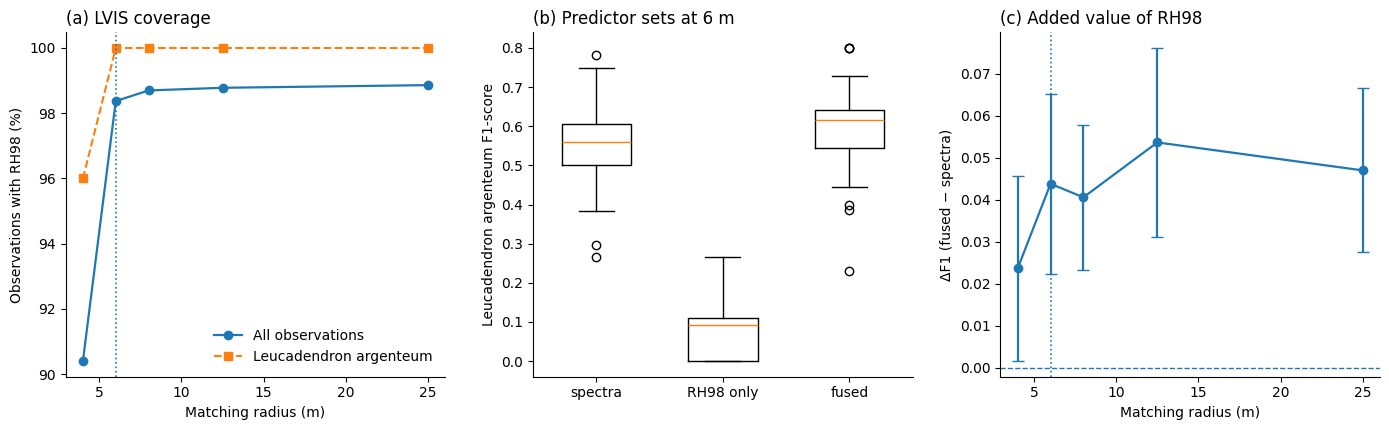

Written: /Users/phemelo/Documents/LesHyperion/outputs/02_matching_fusion/figures/F_matching_and_fusion.png
Written: /Users/phemelo/Documents/LesHyperion/outputs/02_matching_fusion/figures/F_matching_and_fusion.pdf


In [12]:
headline_fold_metrics = fold_metrics[
    fold_metrics["radius_m"]
    == match_radius_m
]


if headline_fold_metrics.empty:
    raise RuntimeError(
        f"No model result is available "
        f"at {match_radius_m:.1f} m."
    )


fig, axes = plt.subplots(
    1,
    3,
    figsize=(
        14,
        4.4,
    ),
)


# ---------------------------------------------------------------
# Panel (a): LVIS coverage
# ---------------------------------------------------------------

axes[0].plot(
    coverage_table["radius_m"],
    coverage_table["pct_with_rh98"],
    marker="o",
    linewidth=1.6,
    label="All observations",
)

axes[0].plot(
    coverage_table["radius_m"],
    coverage_table["pct_target_with_rh98"],
    marker="s",
    linestyle="--",
    linewidth=1.5,
    label=target_species,
)

axes[0].axvline(
    match_radius_m,
    linestyle=":",
    linewidth=1.2,
)

axes[0].set_xlabel(
    "Matching radius (m)"
)

axes[0].set_ylabel(
    "Observations with RH98 (%)"
)

axes[0].set_title(
    "(a) LVIS coverage",
    loc="left",
)

axes[0].legend(
    frameon=False
)


# ---------------------------------------------------------------
# Panel (b): predictor sets at 6 m
# ---------------------------------------------------------------

predictor_order = [
    "spectra",
    "RH98 only",
    "fused",
]

boxplot_data = [
    headline_fold_metrics.loc[
        headline_fold_metrics[
            "predictors"
        ] == predictor,
        "f1",
    ].to_numpy()
    for predictor in predictor_order
]

axes[1].boxplot(
    boxplot_data,
    labels=predictor_order,
    widths=0.55,
)

axes[1].set_ylabel(
    f"{target_species} F1-score"
)

axes[1].set_title(
    f"(b) Predictor sets at "
    f"{match_radius_m:.0f} m",
    loc="left",
)


# ---------------------------------------------------------------
# Panel (c): fused minus spectral F1
# ---------------------------------------------------------------

lower_error = (
    fusion_summary["delta_F1"]
    - fusion_summary[
        "delta_F1_lower_95"
    ]
)

upper_error = (
    fusion_summary[
        "delta_F1_upper_95"
    ]
    - fusion_summary["delta_F1"]
)


axes[2].errorbar(
    fusion_summary["radius_m"],
    fusion_summary["delta_F1"],
    yerr=[
        lower_error,
        upper_error,
    ],
    marker="o",
    linewidth=1.6,
    capsize=4,
)

axes[2].axhline(
    0,
    linestyle="--",
    linewidth=1.0,
)

axes[2].axvline(
    match_radius_m,
    linestyle=":",
    linewidth=1.2,
)

axes[2].set_xlabel(
    "Matching radius (m)"
)

axes[2].set_ylabel(
    "ΔF1 (fused − spectra)"
)

axes[2].set_title(
    "(c) Added value of RH98",
    loc="left",
)


for axis in axes:

    axis.spines[
        "top"
    ].set_visible(False)

    axis.spines[
        "right"
    ].set_visible(False)

    axis.grid(False)


fig.tight_layout(
    w_pad=2.0
)


figure_png = (
    figure_dir
    / "F_matching_and_fusion.png"
)

figure_pdf = (
    figure_dir
    / "F_matching_and_fusion.pdf"
)


fig.savefig(
    figure_png,
    dpi=400,
    bbox_inches="tight",
)

fig.savefig(
    figure_pdf,
    bbox_inches="tight",
)

plt.show()


print(
    f"Written: {figure_png}"
)

print(
    f"Written: {figure_pdf}"
)


## 10. Headline results and manuscript-ready reporting text

The final tables are generated from the objects created above rather than from manually typed values. This keeps the reported sample sizes and performance statistics tied to the actual run.

The reporting text distinguishes feature-level fusion from the later structural filter and states explicitly that the hyperspectral component contains 324 retained AVIRIS-NG bands.


In [13]:
headline_coverage = coverage_table[
    coverage_table["radius_m"]
    == match_radius_m
].iloc[0]

headline_fusion = fusion_summary[
    fusion_summary["radius_m"]
    == match_radius_m
].iloc[0]

headline_filter = filter_summary[
    filter_summary["radius_m"]
    == match_radius_m
].iloc[0]


headline_results = pd.DataFrame({
    "Quantity": [
        "AVIRIS-NG retained bands",
        "AVIRIS-NG observations in analysis library",
        "Headline LVIS matching radius (m)",
        "Observations with RH98 at headline radius",
        "Target observations with RH98 at headline radius",
        "Spectra-only target F1",
        "RH98-only target F1",
        "Fused target F1",
        "Delta F1: fused minus spectra",
        "Delta F1 lower 95%",
        "Delta F1 upper 95%",
        "Tallest field-measured tree (m)",
        "Paired LVIS-field RMSE (m)",
        "Structural upper bound (m)",
        "Structural-filter delta precision",
        "Structural-filter delta recall",
        "Structural-filter delta F1",
    ],
    "Value": [
        expected_retained_bands,
        len(spectral_library),
        match_radius_m,
        int(
            headline_coverage[
                "n_with_rh98"
            ]
        ),
        int(
            headline_coverage[
                "n_target_with_rh98"
            ]
        ),
        headline_fusion[
            "F1_spectra"
        ],
        headline_fusion[
            "F1_RH98"
        ],
        headline_fusion[
            "F1_fused"
        ],
        headline_fusion[
            "delta_F1"
        ],
        headline_fusion[
            "delta_F1_lower_95"
        ],
        headline_fusion[
            "delta_F1_upper_95"
        ],
        field_max_height_m,
        lvis_field_rmse_m,
        upper_height_bound_m,
        headline_filter[
            "delta_precision"
        ],
        headline_filter[
            "delta_recall"
        ],
        headline_filter[
            "delta_f1"
        ],
    ],
})


headline_results.to_csv(
    table_dir
    / "headline_matching_fusion_results.csv",
    index=False,
)


print(
    headline_results
    .to_string(index=False)
)


methods_text = f"""
AVIRIS-NG-LVIS integration

Feature-level sensor fusion used the same {expected_retained_bands}
AVIRIS-NG bands retained by the hyperspectral-classification analysis.
The filtered spectral library was loaded directly from the Part 2 output
rather than re-deriving a wavelength mask in the fusion workflow. Each
spectrum was vector-normalised using the same procedure as the standalone
hyperspectral analysis.

AVIRIS-NG observation coordinates and LVIS shot centres were projected to
{working_crs}. Each spectral observation was assigned the RH98 value of the
nearest quality-filtered LVIS shot when its centre occurred within
{match_radius_m:.0f} m. This radius represents the approximately
{lvis_footprint_diameter_m / 2:.0f} m LVIS footprint radius plus a
{lvis_geolocation_error_m:.0f} m horizontal geolocation allowance. Matching
radii of {", ".join(str(radius) for radius in radius_sweep_m)} m were also
evaluated as a sensitivity analysis.

The spectral-only, RH98-only and fused predictor sets were compared on the
same LVIS-covered observations using repeated {cv_splits}-fold stratified
cross-validation ({cv_repeats} repeats). For the spectral and fused models,
PCA was fitted independently within each training fold and retained {n_pcs}
components. In the fused model, PCA was applied only to the
{expected_retained_bands} spectral variables; RH98 was standardised
separately and appended as an additional structural predictor. XGBoost used
the same parameterisation as the standalone hyperspectral-classification
notebook.

At the headline {match_radius_m:.0f} m radius,
{int(headline_coverage["n_with_rh98"])} observations had an LVIS RH98 match.
The mean target-species F1-score was
{headline_fusion["F1_spectra"]:.3f} for spectra alone and
{headline_fusion["F1_fused"]:.3f} for the fused model, a fold-wise difference
of {headline_fusion["delta_F1"]:+.4f}.

A separate post-classification structural filter rejected target predictions
with RH98 above {upper_height_bound_m:.3f} m. The threshold was inherited
directly from the preceding RH98 analysis and calculated as the tallest
field-measured Silvertree ({field_max_height_m:.2f} m) plus twice the paired
LVIS-to-field RMSE ({lvis_field_rmse_m:.4f} m). The unrounded value was used
for filtering. The filter was evaluated separately from feature-level fusion
because it constrains predictions after classification rather than adding RH98
to the classifier itself.
""".strip()


methods_path = (
    output_dir
    / "methods_text.txt"
)

methods_path.write_text(
    methods_text,
    encoding="utf-8",
)


print(
    f"\nWritten: {methods_path}"
)


                                        Quantity       Value
                        AVIRIS-NG retained bands  324.000000
      AVIRIS-NG observations in analysis library 1229.000000
               Headline LVIS matching radius (m)    6.000000
       Observations with RH98 at headline radius 1209.000000
Target observations with RH98 at headline radius   50.000000
                          Spectra-only target F1    0.555619
                             RH98-only target F1    0.076952
                                 Fused target F1    0.599465
                   Delta F1: fused minus spectra    0.043847
                              Delta F1 lower 95%    0.022375
                              Delta F1 upper 95%    0.065318
                 Tallest field-measured tree (m)   10.200000
                      Paired LVIS-field RMSE (m)    0.989039
                      Structural upper bound (m)   12.178078
               Structural-filter delta precision    0.044578
                  Struct

## 11. Output audit

The notebook ends by listing the files it created. This is useful when the analysis is rerun with a different matching radius, LVIS cache, or data revision.


In [14]:
print("Tables:")

for table_file in sorted(
    table_dir.glob("*.csv")
):
    print(
        f"  {table_file.name}"
    )


print("\nFigures:")

for figure_file in sorted(
    figure_dir.glob("*")
):
    print(
        f"  {figure_file.name}"
    )


print("\nRasters:")

for raster_file in sorted(
    raster_dir.glob("*.tif")
):
    print(
        f"  {raster_file.name}"
    )


print("\nOther outputs:")

for other_file in sorted(
    output_dir.glob("*.txt")
):
    print(
        f"  {other_file.name}"
    )


Tables:
  T_fusion_by_radius.csv
  T_fusion_folds.csv
  T_matching_radius_coverage.csv
  T_spectral_oof_predictions_with_rh98.csv
  T_structural_filter_by_radius.csv
  T_structural_filter_folds.csv
  headline_matching_fusion_results.csv
  matched_observations_6m.csv

Figures:
  F_matching_and_fusion.pdf
  F_matching_and_fusion.png

Rasters:
  lvis_rh98_8m.tif

Other outputs:
  methods_text.txt
